# Final Project

## PART 1: Preprocessing
- Removed null values
- Normalized specific columns

In [186]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as SKLogReg
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, roc_auc_score, mean_squared_error
from scipy.sparse.linalg import svds
import statsmodels.api as sm

## Load Data & Initial Glance

In [187]:
#Load data
df = pd.read_csv('dataset.csv')
print(f"Shape : {df.shape}\n")
print(df.info())

Shape : (114000, 21)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16

In [188]:
print("Initial glance at data...\n")
display(df.head())

Initial glance at data...



,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Data Types

In [189]:
#Data Types: Check

#Drop 'Unnamed: 0' since is duplicate of the index
df.drop(columns='Unnamed: 0', inplace=True)
print("Dropped 'Unnamed: 0' (redundant row index).")

#Key and mode are int64 but could be categorical:
print("Key & Mode: kept as integers so numeric operations work; treat as categorical for models.")
print(f'\nkey unique values : \n{sorted(df["key"].unique())}') #key  : pitch class 0=C, 1=C#, ... 11=B, -1=no key detected
print(f'\nmode unique values : \n{sorted(df["mode"].unique())}') #mode : 0=minor, 1=major

Dropped 'Unnamed: 0' (redundant row index).
Key & Mode: kept as integers so numeric operations work; treat as categorical for models.

key unique values : 
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]

mode unique values : 
[np.int64(0), np.int64(1)]


## Categorical Features

In [190]:
#Unique counts per object column
obj_cols = df.select_dtypes('object').columns
cat_summary = pd.DataFrame({
    'unique_values' : df[obj_cols].nunique(),
    'sample_values' : [df[c].dropna().unique()[:5].tolist() for c in obj_cols]
})
display(cat_summary)

#Column cardinality audit
cardinality = df[obj_cols].nunique().sort_values()
print('Unique value counts per object column:')
for col, n in cardinality.items():
    tag = 'ID/free-text' if n > 1000 else ('low-cardinality categorical' if n <= 20 else 'medium')
    print(f'  {col:<30} {n:>7,}  ({tag})')

,unique_values,sample_values
track_id,89741,"[5SuOikwiRyPMVoIQDJUgSV, 4qPNDBW1i3p13qLCt0Ki3..."
artists,31437,"[Gen Hoshino, Ben Woodward, Ingrid Michaelson;..."
album_name,46589,"[Comedy, Ghost (Acoustic), To Begin Again, Cra..."
track_name,73608,"[Comedy, Ghost - Acoustic, To Begin Again, Can..."
track_genre,114,"[acoustic, afrobeat, alt-rock, alternative, am..."


Unique value counts per object column:
  track_genre                        114  (medium)
  artists                         31,437  (ID/free-text)
  album_name                      46,589  (ID/free-text)
  track_name                      73,608  (ID/free-text)
  track_id                        89,741  (ID/free-text)


In [191]:
#Categorical summary

obj_cols = df.select_dtypes('object').columns
categorical_summary = pd.DataFrame({
    'unique_values': df[obj_cols].nunique(),
    'sample_values': [df[c].dropna().unique()[:5].tolist() for c in obj_cols]
})

print("Categorical columns: None to convert.\n")
display(categorical_summary)

Categorical columns: None to convert.



,unique_values,sample_values
track_id,89741,"[5SuOikwiRyPMVoIQDJUgSV, 4qPNDBW1i3p13qLCt0Ki3..."
artists,31437,"[Gen Hoshino, Ben Woodward, Ingrid Michaelson;..."
album_name,46589,"[Comedy, Ghost (Acoustic), To Begin Again, Cra..."
track_name,73608,"[Comedy, Ghost - Acoustic, To Begin Again, Can..."
track_genre,114,"[acoustic, afrobeat, alt-rock, alternative, am..."


## Numerical Features

In [192]:
print("Numerical columns: Appear to have some outliers.\n")
df.describe().round(2)

Numerical columns: Appear to have some outliers.



,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00
mean,33.24,228029.15,0.57,0.64,5.31,-8.26,0.64,0.08,0.31,0.16,0.21,0.47,122.15,3.90
std,22.31,107297.71,0.17,0.25,3.56,5.03,0.48,0.11,0.33,0.31,0.19,0.26,29.98,0.43
min,0.00,0.00,0.00,0.00,0.00,-49.53,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,17.00,174066.00,0.46,0.47,2.00,-10.01,0.00,0.04,0.02,0.00,0.10,0.26,99.22,4.00
50%,35.00,212906.00,0.58,0.68,5.00,-7.00,1.00,0.05,0.17,0.00,0.13,0.46,122.02,4.00
75%,50.00,261506.00,0.70,0.85,8.00,-5.00,1.00,0.08,0.60,0.05,0.27,0.68,140.07,4.00
max,100.00,5237295.00,0.98,1.00,11.00,4.53,1.00,0.96,1.00,1.00,1.00,1.00,243.37,5.00


In [193]:
#IQR-based outlier detection: numeric columns

numeric_cols = df.select_dtypes(include='number').columns.tolist()
outlier_summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({'column': col, 'lower_fence': round(lower,2),
                            'upper_fence': round(upper,2), 'outlier_count': n_out,
                            'outlier_pct': round(n_out / len(df) * 100, 2)})

outlier_df = pd.DataFrame(outlier_summary).sort_values('outlier_count', ascending=False)
display(outlier_df)

,column,lower_fence,upper_fence,outlier_count,outlier_pct
9,instrumentalness,-0.07,0.12,25246,22.15
7,speechiness,-0.04,0.16,13211,11.59
13,time_signature,4.00,4.00,12157,10.66
10,liveness,-0.16,0.54,8642,7.58
5,loudness,-17.53,2.51,6173,5.41
1,duration_ms,42906.00,392666.00,5617,4.93
2,danceability,0.10,1.05,620,0.54
12,tempo,37.94,201.35,617,0.54
0,popularity,-32.50,99.50,2,0.00
3,energy,-0.10,1.43,0,0.00


## Outlier Handling Decisions
It appears that instrumentalness, speechiness, time_signature, liveness, loudness, and duration_ms have a large percent of outliers (~5%). Otherwise, the danceability outliers are too few, tempo is boundless, and popularity is included [0,100]. The others will be handled as below:  

**Keep same: Instrumentalness, Speechiness, Liveness:**
-   Heavily right-skewed — majority near 0, with a long tail of genuinely high-scoring tracks. Values above 0.5 for instrumentalness are intended to represent instrumental tracks, and a liveness value above 0.8 provides strongly means the track is live. IQR flags these because it assumes a roughly symmetric distribution, which these clearly aren't. The "outliers" are just classical pieces, spoken word albums, and live recordings.  

**Encode as categorical: Time_signature:**
-   Gets flagged because the time signature ranges from 3 to 7 indicating time signatures of "3/4" to "7/4" — but 4/4 is so dominant in pop music that all else looks like outliers. They're not; they're just minority time signatures. Treating it as a numeric column would be wrong.  

**Remove rows: Loudness, Duration_ms:**
-   The only two where actual row removal is justified — loudness physically cannot exceed 0 dB, and tracks under 20 seconds or over 30 minutes are likely intros, outros, audiobooks, or sound effects that would distort analysis.

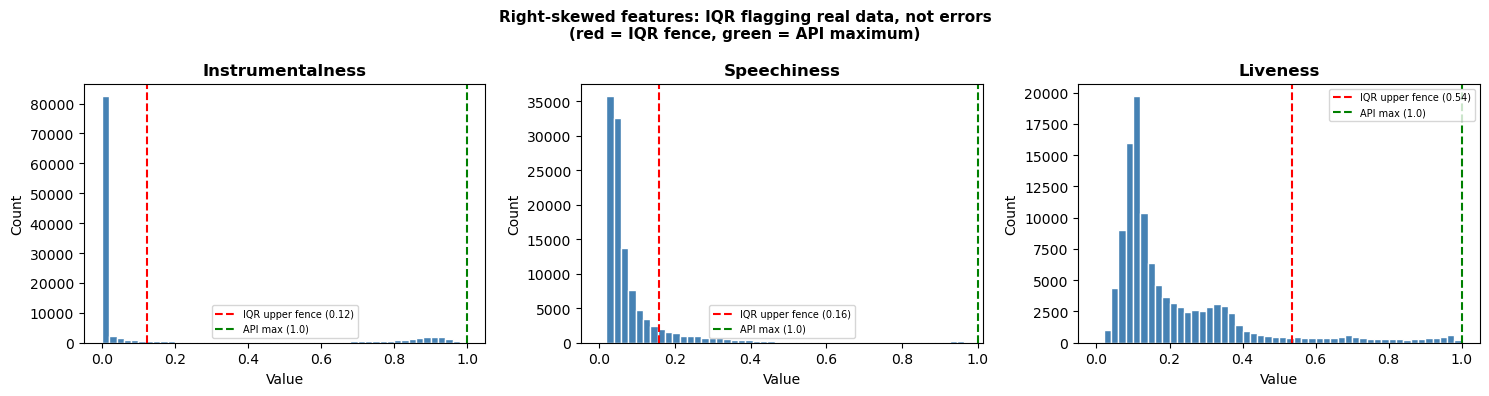

In [194]:
#Visualise the skewed audio feature distributions: Why IQR over-flags
skewed_features = ['instrumentalness', 'speechiness', 'liveness']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, skewed_features):
    ax.hist(df[col], bins=50, color='steelblue', edgecolor='white')
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_fence = Q3 + 1.5 * IQR
    ax.axvline(upper_fence, color='red', linestyle='--', label=f'IQR upper fence ({upper_fence:.2f})')
    ax.axvline(1.0, color='green', linestyle='--', label='API max (1.0)')
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

plt.suptitle('Right-skewed features: IQR flagging real data, not errors\n'
             '(red = IQR fence, green = API maximum)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [195]:
#Time Signature: Encode categorical 

#Valid Spotify API values: 3, 4, 5, 6, 7 (representing x/4 time) ... flag those outside range as invalid
print('time_signature value counts (before):')
print(df['time_signature'].value_counts().sort_index())
valid_ts = [3, 4, 5, 6, 7]
invalid_ts = ~df['time_signature'].isin(valid_ts)
print(f'\nValues outside valid range [3–7]: {invalid_ts.sum():,}')

df = df[df['time_signature'].isin(valid_ts)].copy()
df['time_signature'] = pd.Categorical(df['time_signature'], categories=valid_ts, ordered=True)
print('time_signature recoded as ordered categorical.')

time_signature value counts (before):
time_signature
0       163
1       973
3      9195
4    101843
5      1826
Name: count, dtype: int64

Values outside valid range [3–7]: 1,136
time_signature recoded as ordered categorical.


In [196]:
#loudness: Inspect extremes

#Spotify docs: loudness in dB, 'typically between -60 and 0 dB'. Positive dB not impossible.
print('loudness descriptive stats:')
print(df['loudness'].describe().round(2))

n_loud_low  = (df['loudness'] < -60).sum()
n_loud_high = (df['loudness'] > 0.5).sum()   
print(f'\nValues below -60 dB : {n_loud_low:,}')
print(f'Values above   +0.5 dB : {n_loud_high:,}')

#Inspect before removing
if n_loud_low > 0:
    print('\nSample of tracks with loudness < -60 dB:')
    display(df[df['loudness'] < -60][['track_name', 'artists', 'track_genre', 'loudness']].head(8))
if n_loud_high > 0:
    print('\nSample of tracks with loudness > +1 dB:')
    display(df[df['loudness'] > 0.5][['track_name', 'artists', 'track_genre', 'loudness']].head(8))

#Remove only implausible extremes
before = len(df)
df = df[(df['loudness'] >= -60) & (df['loudness'] <= 0.5)]
print(f'\nRemoved {before - len(df):,} rows with implausible loudness. Remaining: {len(df):,}')
print('Note: mildly positive dB (0 to +0.5) kept - possible for heavily compressed tracks.')

loudness descriptive stats:
count    112864.00
mean         -8.20
std           4.95
min         -46.59
25%          -9.96
50%          -6.98
75%          -4.99
max           4.53
Name: loudness, dtype: float64

Values below -60 dB : 0
Values above   +0.5 dB : 47

Sample of tracks with loudness > +1 dB:


,track_name,artists,track_genre,loudness
5307,それは小さな光のような,Sayuri,anime,0.698
5710,それは小さな光のような,Sayuri,anime,0.698
17574,Fate Dance,Five Star Hotel,club,4.532
17590,Eternity or Something,Free Refills,club,0.777
17788,The Mall,Free Refills,club,1.673
17886,Silicone,Free Refills,club,0.665
17895,Malfunction,Free Refills,club,1.795
27022,Gold Dust - Fox Stevenson Remix,DJ Fresh;Fox Stevenson,drum-and-bass,0.836



Removed 47 rows with implausible loudness. Remaining: 112,817
Note: mildly positive dB (0 to +0.5) kept - possible for heavily compressed tracks.


In [197]:
#Duration_ms: Inspect extremes

print('duration_ms descriptive stats (in minutes for readability):')
dur_min = df['duration_ms'] / 60000
print(dur_min.describe().round(2))

#Tracks under 20 seconds or over 30 minutes are probably not songs
SHORT_MS = 20_000     # 20 seconds
LONG_MS  = 1_800_000  # 30 minutes
n_short = (df['duration_ms'] < SHORT_MS).sum()
n_long  = (df['duration_ms'] > LONG_MS).sum()
print(f'\nTracks under 20 seconds  : {n_short:,}')
print(f'Tracks over 30 minutes  : {n_long:,}')

#Sample extremes to verify they're not valid edge cases
if n_short > 0:
    print('\nShortest tracks (sample):')
    display(df.nsmallest(5, 'duration_ms')[['track_name', 'artists', 'duration_ms', 'track_genre']])
if n_long > 0:
    print('\nLongest tracks (sample):')
    display(df.nlargest(5, 'duration_ms')[['track_name', 'artists', 'duration_ms', 'track_genre']])

duration_ms descriptive stats (in minutes for readability):
count    112817.00
mean          3.80
std           1.77
min           0.00
25%           2.91
50%           3.55
75%           4.36
max          87.29
Name: duration_ms, dtype: float64

Tracks under 20 seconds  : 3
Tracks over 30 minutes  : 34

Shortest tracks (sample):


,track_name,artists,duration_ms,track_genre
65900,NaN,NaN,0,k-pop
59775,Screams for a Finale! (feat. Leila's Opera Class),Leila Bela;Leila's Opera Class,15800,iranian
16856,"Andante in C Major, K. 1a",Wolfgang Amadeus Mozart;Ingrid Haebler,17453,classical
59306,V-7,Leila Bela,21120,iranian
59609,Shatter,Leila Bela,21240,iranian



Longest tracks (sample):


,track_name,artists,duration_ms,track_genre
73617,Unity (Voyage Mix) Pt. 1,Tale Of Us,5237295,minimal-techno
10935,Crossing Wires 002 - Continuous DJ Mix,Timo Maas,4789026,breakbeat
10984,Crossing Wires 002 - Continuous DJ Mix,Timo Maas,4789026,breakbeat
24348,The Lab 03 - Continuous DJ Mix Part 1,Seth Troxler,4730302,detroit-techno
73840,Amnesia Ibiza Underground 10 DJ Mix,Loco Dice,4563897,minimal-techno


Removed 37 extreme-duration rows. Remaining: 112,780
Added duration_min column (duration_ms ÷ 60,000).


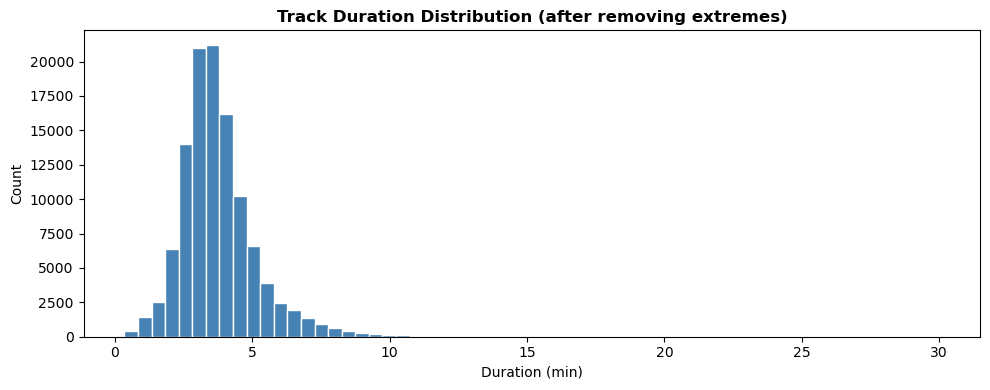

In [198]:
#Remove duration outliers (intros, audiobooks, misclassified content)
before = len(df)
df = df[(df['duration_ms'] >= SHORT_MS) & (df['duration_ms'] <= LONG_MS)]
print(f'Removed {before - len(df):,} extreme-duration rows. Remaining: {len(df):,}')

#Convert to minutes for interpretation
df['duration_min'] = (df['duration_ms'] / 60000).round(3)
print('Added duration_min column (duration_ms ÷ 60,000).')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['duration_min'], bins=60, color='steelblue', edgecolor='white')
ax.set_title('Track Duration Distribution (after removing extremes)', fontweight='bold')
ax.set_xlabel('Duration (min)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [199]:
#Summary: Outliers kept vs. removed 
print('Outlier handling summary:')
print(f'  instrumentalness  → KEPT  (right-skewed but valid 0–1 range)')
print(f'  speechiness       → KEPT  (right-skewed but valid 0–1 range)')
print(f'  liveness          → KEPT  (right-skewed but valid 0–1 range)')
print(f'  time_signature    → KEPT, recoded as ordered categorical [3–7]')
print(f'  loudness          → ROWS REMOVED outside [-60, 0] dB')
print(f'  duration_ms       → ROWS REMOVED outside [20s, 30min]; duration_min added')
print(f'  danceability      → KEPT  (0.54% flagged, all within valid range)')
print(f'  tempo             → KEPT  (0.54% flagged, extreme BPM is musically real)')
print(f'  popularity        → KEPT  (2 flagged rows, negligible)')
print(f'\nFinal shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Outlier handling summary:
  instrumentalness  → KEPT  (right-skewed but valid 0–1 range)
  speechiness       → KEPT  (right-skewed but valid 0–1 range)
  liveness          → KEPT  (right-skewed but valid 0–1 range)
  time_signature    → KEPT, recoded as ordered categorical [3–7]
  loudness          → ROWS REMOVED outside [-60, 0] dB
  duration_ms       → ROWS REMOVED outside [20s, 30min]; duration_min added
  danceability      → KEPT  (0.54% flagged, all within valid range)
  tempo             → KEPT  (0.54% flagged, extreme BPM is musically real)
  popularity        → KEPT  (2 flagged rows, negligible)

Final shape: 112,780 rows × 21 columns


## Whitespace

In [200]:
#Whitespace: Leading/trailing
str_cols = df.select_dtypes('object').columns.tolist()

print('Columns with leading/trailing whitespace in ≥1 value:')
ws_found = False
for col in str_cols:
    vals = df[col].dropna().astype(str)
    n_diff = (vals != vals.str.strip()).sum()
    if n_diff > 0:
        print(f'  -{col}: {n_diff:,} values have leading/trailing whitespace')
        ws_found = True

if not ws_found:
    print('  ✓ No whitespace issues found')
else:
    for col in str_cols:
        df[col] = df[col].astype(str).str.strip()
    print('\n--> Stripped all string columns.')

#Check artists for spaces around the ; separator (e.g. 'Adele ; Zayn')
space_around_semi = df['artists'].dropna().astype(str).str.contains(r'\s;|;\s', regex=True).sum()
print(f'\nartists with spaces around the ; separator: {space_around_semi:,}')
if space_around_semi > 0:
    df['artists'] = df['artists'].str.replace(r'\s*;\s*', ';', regex=True)
    print('  → Normalised spacing around ; in artists.')

Columns with leading/trailing whitespace in ≥1 value:
  -artists: 8 values have leading/trailing whitespace

--> Stripped all string columns.

artists with spaces around the ; separator: 0


## Duplicates

In [201]:
#Exact duplicate rows
n_exact = df.duplicated().sum()
print(f'Exact duplicate rows : {n_exact:,}')

#Duplicate track_ids
# Note: dataset assigns one row per track per genre, so same song can appear under multiple genres - that is intentional.
n_dup_ids = df.duplicated(subset='track_id').sum()
print(f'Duplicate track_ids  : {n_dup_ids:,}  (expected — same track, different genres)')

if n_dup_ids > 0:
    print('\nExample — same track in multiple genres. Will not remove these:')
    example_id = df[df.duplicated(subset='track_id', keep=False)]['track_id'].iloc[0]
    display(df[df['track_id'] == example_id][['track_name', 'artists', 'track_genre']])

#Drop only true exact duplicates (all 20 columns same)
if n_exact > 0:
    df = df.drop_duplicates()
    print(f'\n→ Removed {n_exact:,} exact duplicate rows. New shape: {df.shape}')
else:
    print('\n✓ No exact duplicates to remove.')

Exact duplicate rows : 443
Duplicate track_ids  : 24,118  (expected — same track, different genres)

Example — same track in multiple genres. Will not remove these:


,track_name,artists,track_genre
0,Comedy,Gen Hoshino,acoustic
62102,Comedy,Gen Hoshino,j-pop
99152,Comedy,Gen Hoshino,singer-songwriter
102151,Comedy,Gen Hoshino,songwriter



→ Removed 443 exact duplicate rows. New shape: (112337, 21)


Otherwise...
No string columns with embedded units (e.g. $, #, GB, %).  
No hidden characters.  
No inconsistent formatting or casing for categorical columns.  
No inconsistent units in numerical columns.    
No invalid (negative) value counts.

## PART 2: Data Visualization

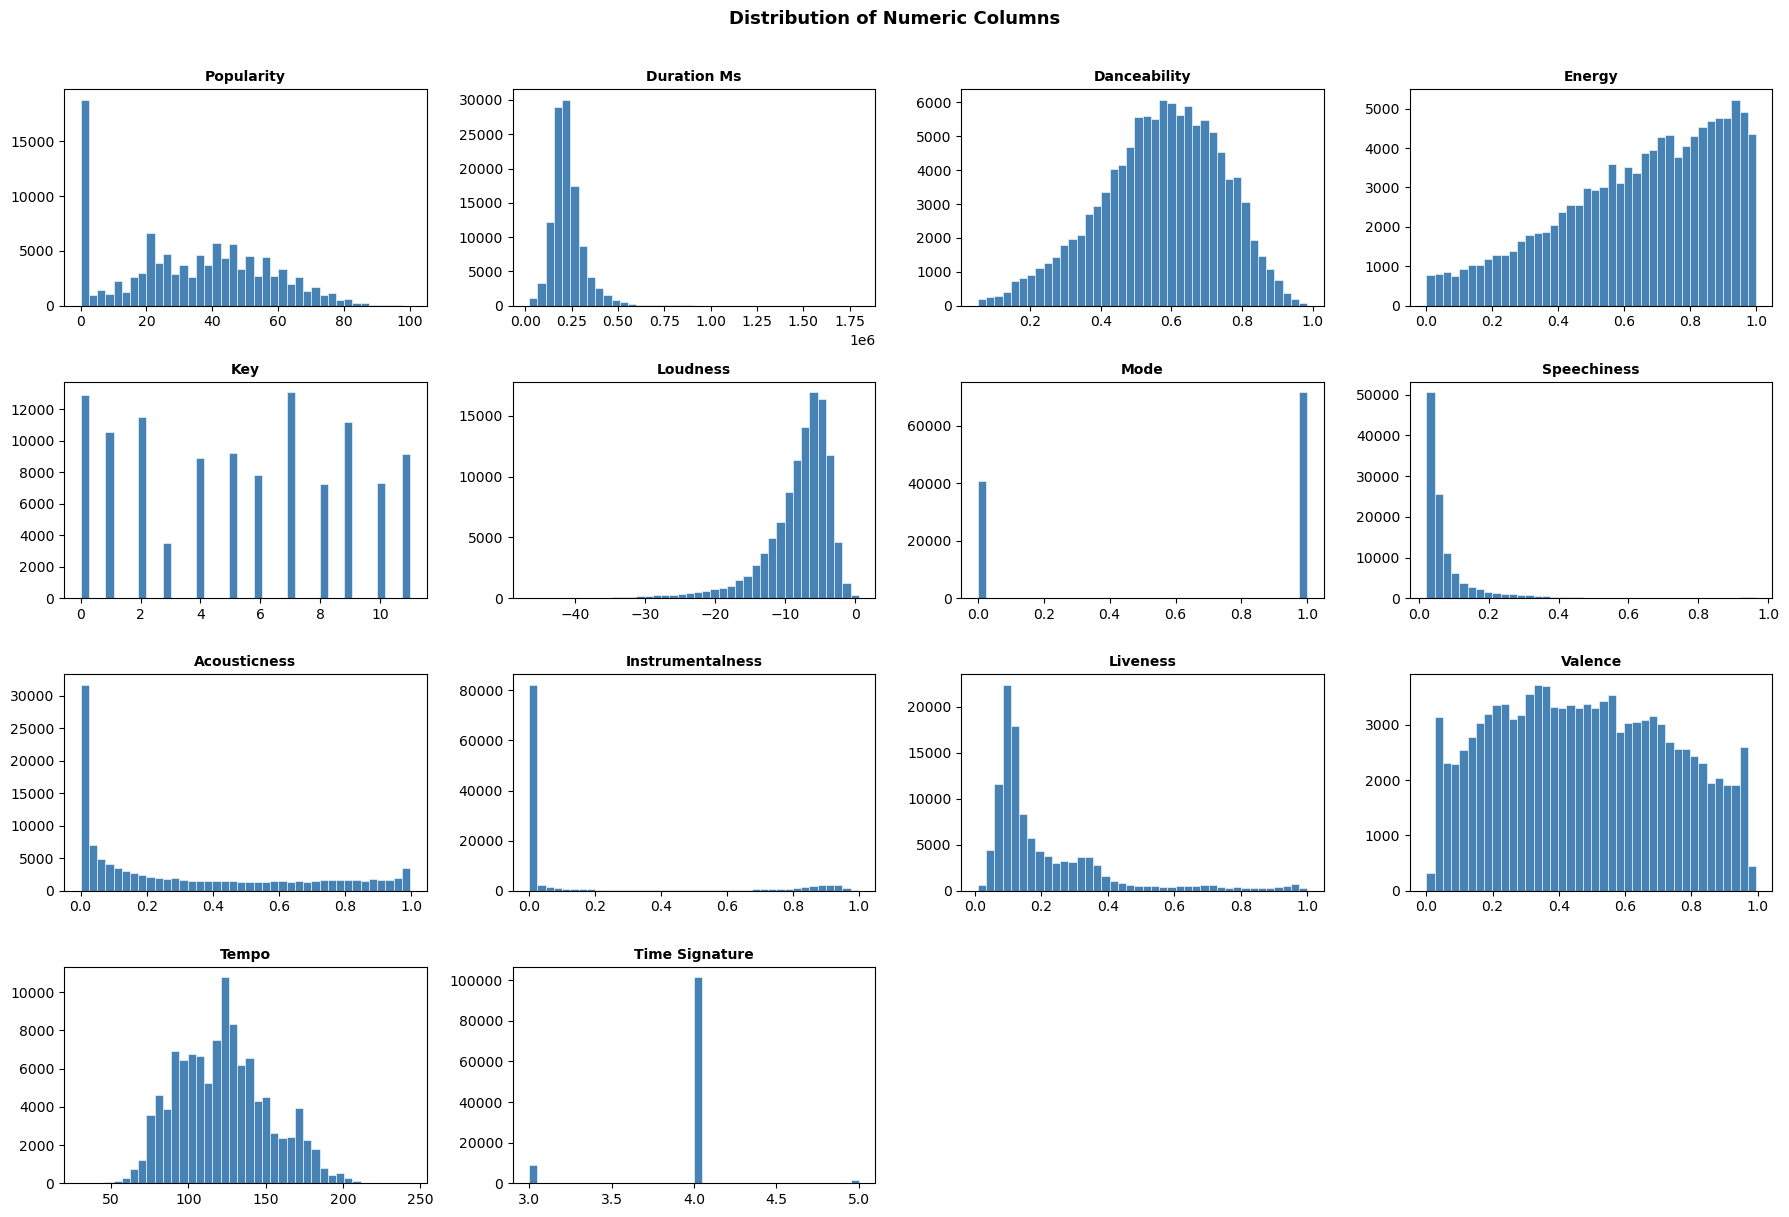

In [202]:
#Numeric column distributions
key_num = ['popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode',
           'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
fig, axes = plt.subplots(4, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(key_num):
    if col in df.columns:
        axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
        axes[i].set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
        axes[i].set_xlabel('')

for j in range(len(key_num), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numeric Columns', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

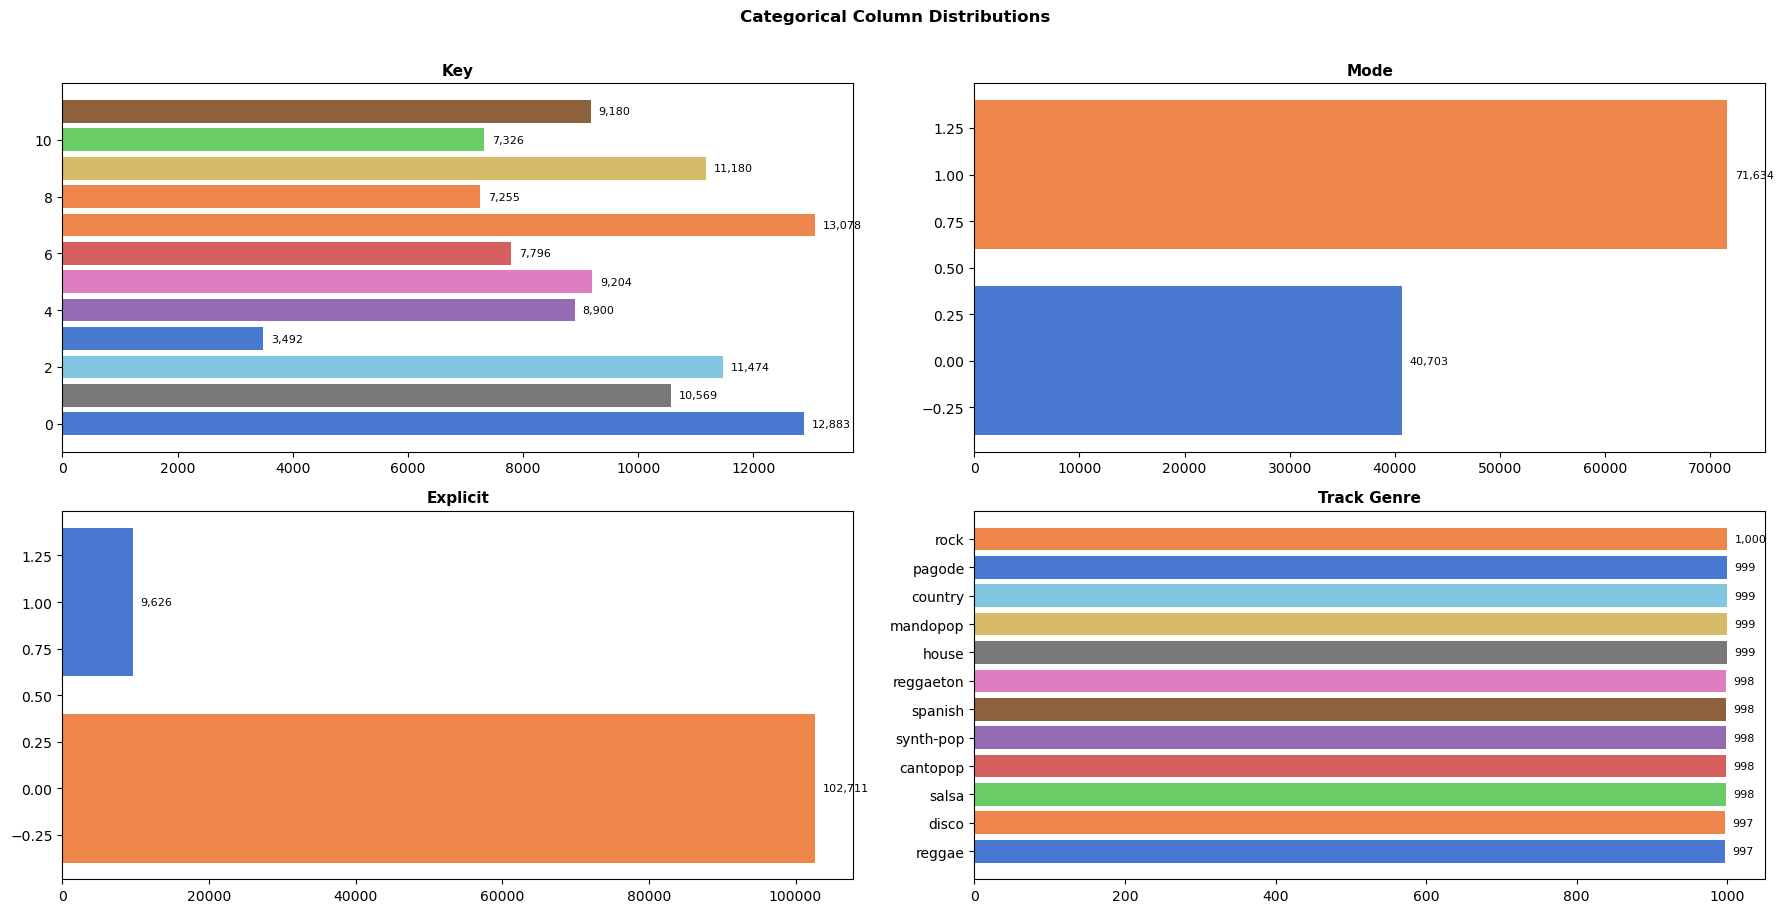

In [203]:
#Categorical column visualizations
cat_cols_vis = ['key', 'mode', 'explicit', 'track_genre']
fig, axes = plt.subplots(2, 2, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols_vis):
    counts = df[col].value_counts().head(12)
    axes[i].barh(counts.index[::-1], counts.values[::-1], color=sns.color_palette('muted', len(counts)))
    axes[i].set_title(col.replace('_',' ').title(), fontweight='bold', fontsize=11)
    for bar, val in zip(axes[i].patches, counts.values[::-1]):
        axes[i].text(bar.get_width() + counts.values.max()*0.01,
                     bar.get_y() + bar.get_height()/2,
                     f'{val:,}', va='center', fontsize=8)

plt.suptitle('Categorical Column Distributions', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

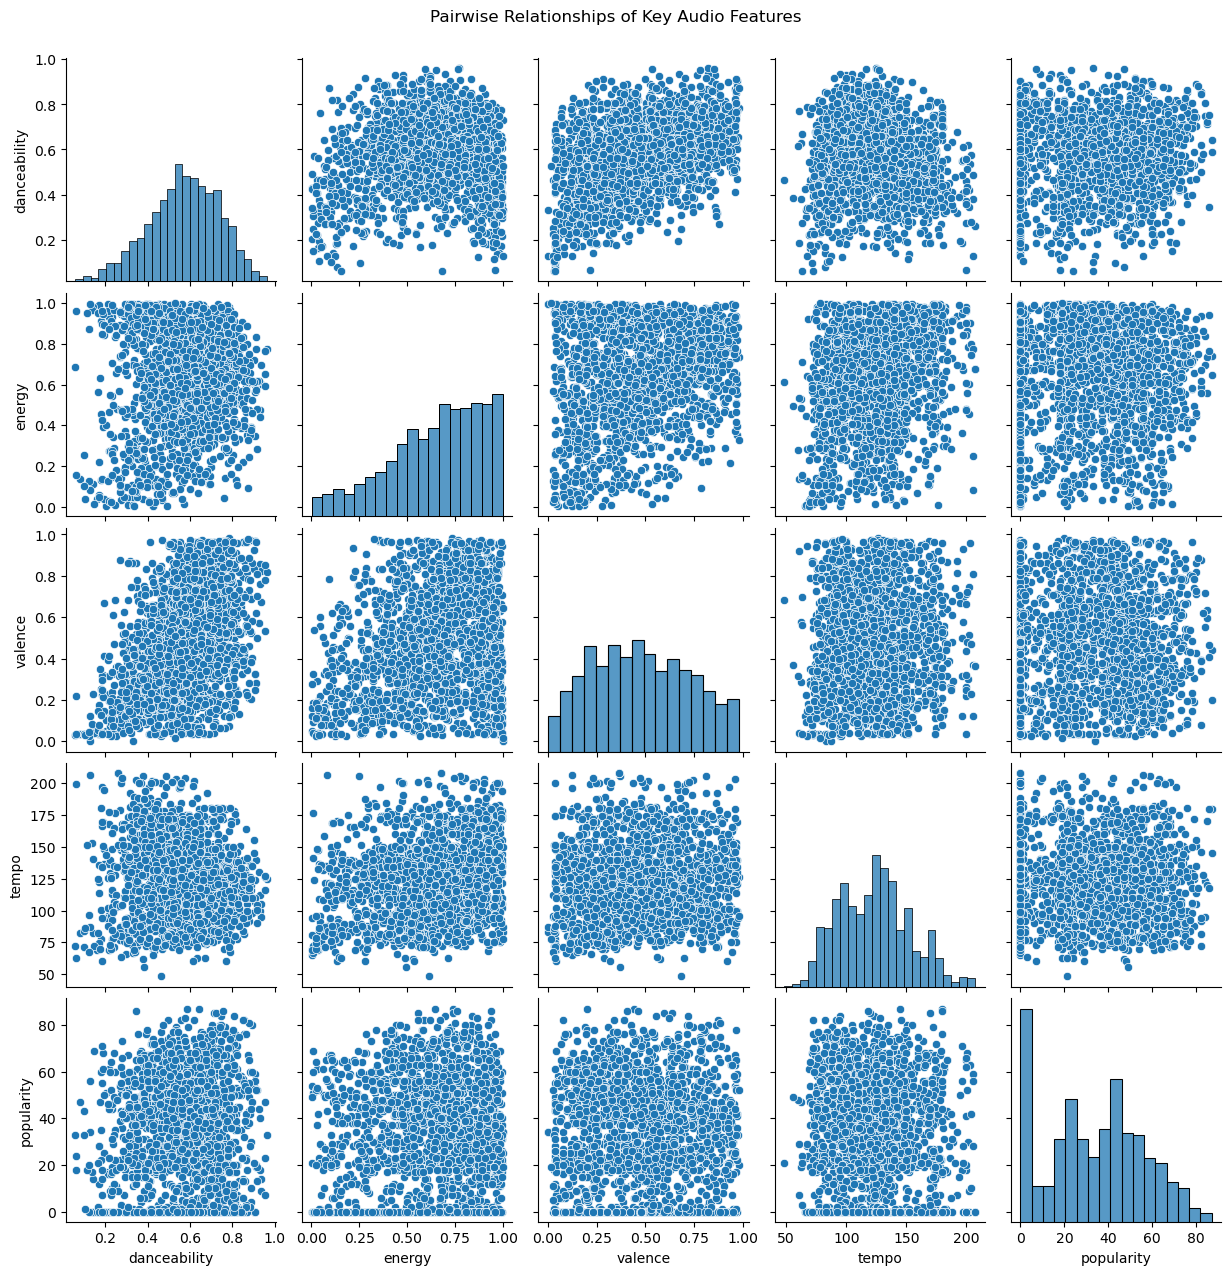

In [204]:
#Pair-wise plot: Key Audio Features
key_features = ['danceability', 'energy', 'valence', 'tempo', 'popularity']

sns.pairplot(df[key_features].sample(2000))
plt.suptitle('Pairwise Relationships of Key Audio Features', y=1.02)
plt.show()

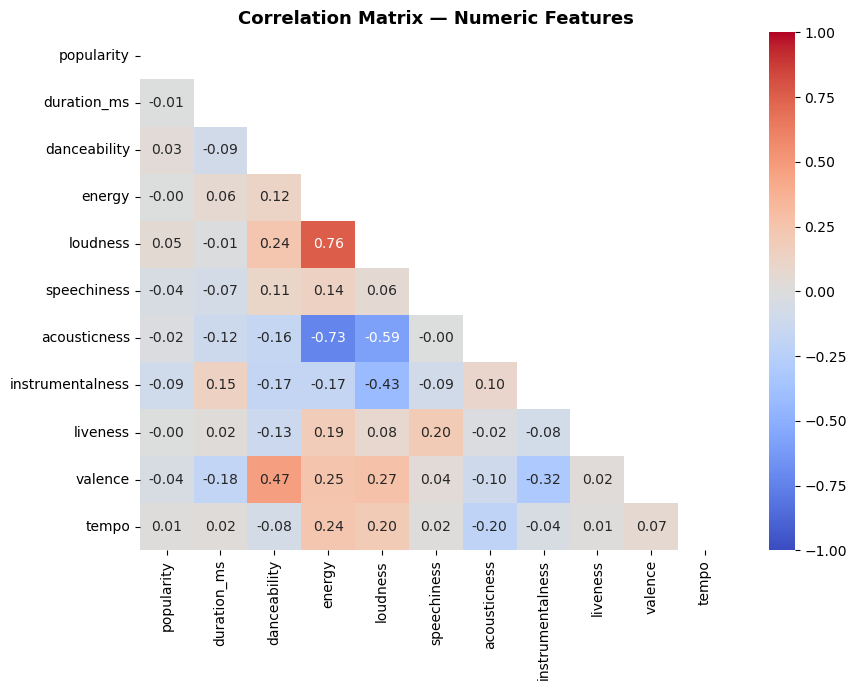

In [205]:
#Correlation Heatmap: numerical columns
num_cols = ['popularity', 'duration_ms', 'danceability', 'energy',
            'loudness', 'speechiness', 'acousticness',
            'instrumentalness', 'liveness', 'valence', 'tempo']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

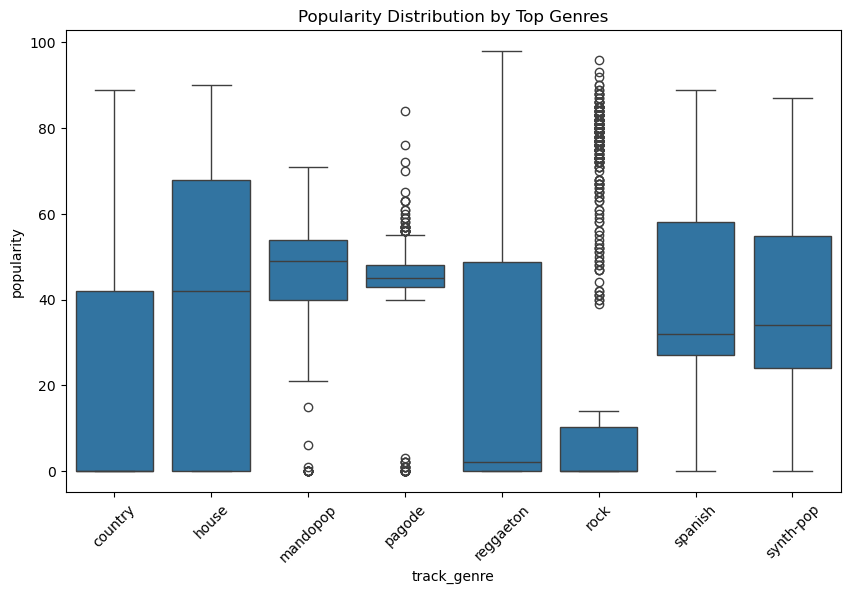

In [206]:
#Box plot: Popularity by Track genre
top_genres = df['track_genre'].value_counts().head(8).index
subset = df[df['track_genre'].isin(top_genres)]

plt.figure(figsize=(10,6))
sns.boxplot(x='track_genre', y='popularity', data=subset)
plt.xticks(rotation=45)
plt.title('Popularity Distribution by Top Genres')
plt.show()

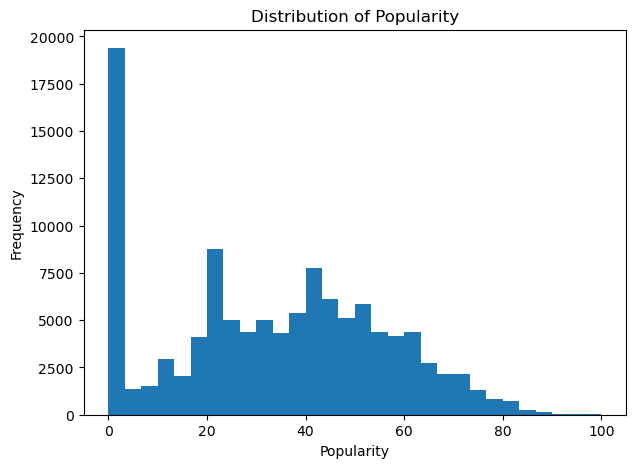

In [207]:
#Histogram: popularity
plt.figure(figsize=(7,5))
plt.hist(df['popularity'], bins=30)
plt.title('Distribution of Popularity')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.show()

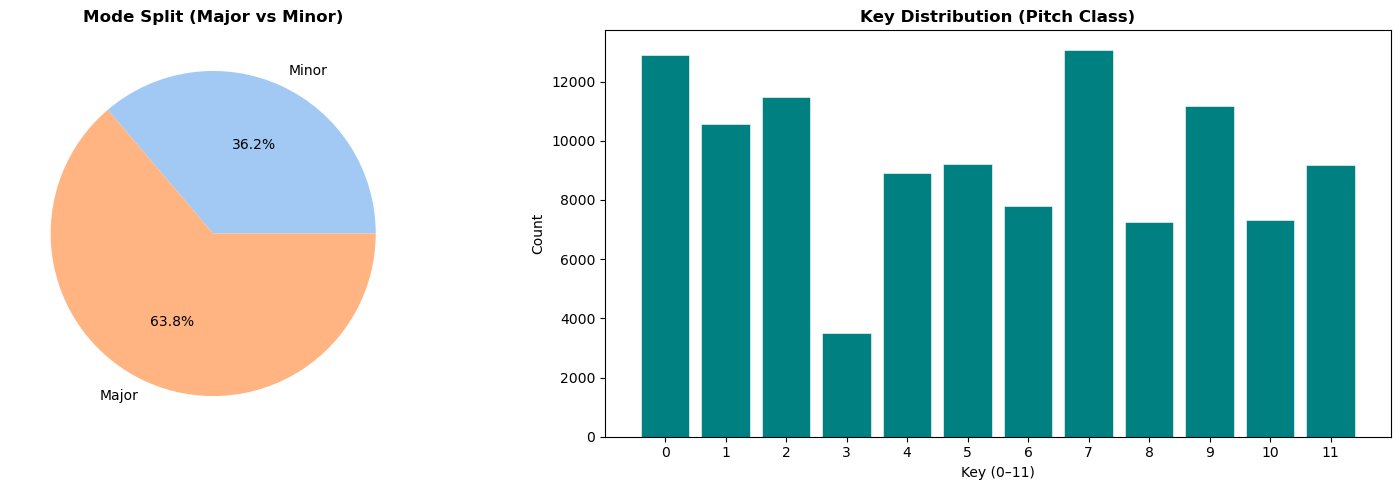

In [208]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

#Mode split (major vs minor)
mode_counts = df['mode'].value_counts().sort_index()
mode_labels = ['Minor', 'Major'] if len(mode_counts) == 2 else mode_counts.index
axes[0].pie(mode_counts.values, labels=mode_labels, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
axes[0].set_title('Mode Split (Major vs Minor)', fontweight='bold')

#Key distribution (0–11 treated categorical)
key_counts = df['key'].value_counts().sort_index()
axes[1].bar(key_counts.index.astype(str), key_counts.values, color='teal', edgecolor='white', linewidth=0.4)
axes[1].set_title('Key Distribution (Pitch Class)', fontweight='bold')
axes[1].set_xlabel('Key (0–11)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

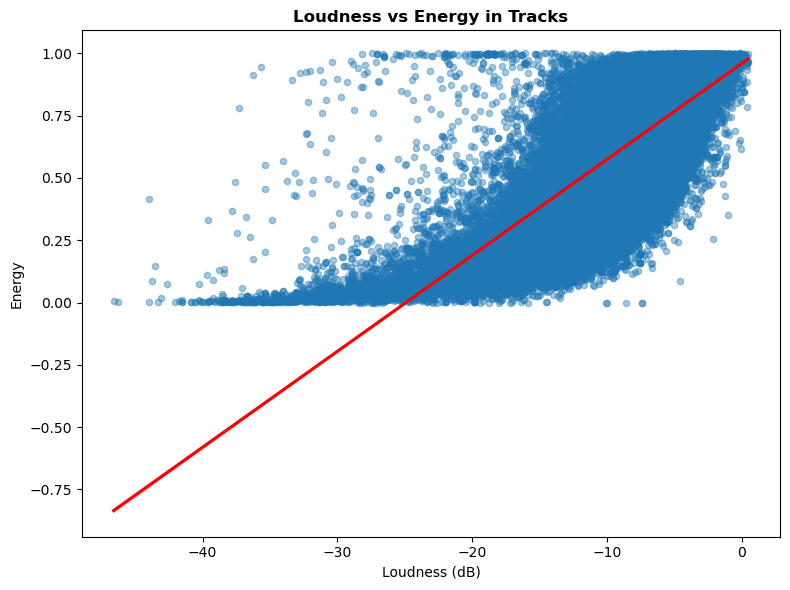

In [209]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='loudness', y='energy', scatter_kws={'alpha': 0.4, 's': 20}, line_kws={'color': 'red'})

plt.title('Loudness vs Energy in Tracks', fontweight='bold')
plt.xlabel('Loudness (dB)')
plt.ylabel('Energy')
plt.tight_layout()
plt.show()

In [210]:
df.to_csv('cleaned_spotify.csv', index=False)